# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 9: Credit Scoring Tradicional vs Machine Learning..**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

warnings.filterwarnings("ignore")

np.random.seed(42)

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s08")
src_path = os.path.join(absolute_path, "src", "s08")
model_path = os.path.join(absolute_path, "models", "s08")
figure_path = os.path.join(absolute_path, "figuras", "s08")
sys.path.insert(0, src_path)

PALETTE = ['#2C5F8A', '#E8523A', '#2CA02C', '#FF7F0E', '#9467BD', '#8C564B']
sns.set_palette(PALETTE)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 🎯 **Objetivos de la sesión**

Al finalizar esta sesión, el participante será capaz de:

1. Reconocer las **limitaciones técnicas y regulatorias** de los modelos tradicionales de scoring.
2. Identificar y clasificar los principales **algoritmos de Machine Learning** aplicables al crédito.
3. Comparar ambos enfoques en dimensiones de **rendimiento, interpretabilidad y gobernanza**.
4. Ejecutar un **benchmark empírico** sobre un dataset de crédito real.
5. Articular un **framework de decisión** para seleccionar el enfoque adecuado según el contexto instituciona


# 🔁 **1. Recapitulación y Motivación**

## **1.1 ¿Qué construimos en el Curso I?**

En las primeras ocho sesiones construimos el **pipeline clásico de credit scoring** basado en regresión logística:

```
Datos Brutos
    ↓
Definición del Evento de Incumplimiento (Sesión 2)
    ↓
EDA + Tratamiento de variables (Sesión 3)
    ↓
WOE / IV (Sesión 4)
    ↓
Regresión Logística (Sesión 5)
    ↓
Evaluación: Gini, KS, AUC (Sesión 6)
    ↓
Validación + PSI/CSI (Sesión 7)
    ↓
Scorecard + Puntos de corte (Sesión 8)
```

Este pipeline es **sólido, regulatoriamente aceptado y ampliamente utilizado** en la banca tradicional. Pero tiene limitaciones que exploraremos en esta sesión.

## **1.2 ¿Por qué transicionar hacia Machine Learning?**

Cuatro fuerzas impulsoras del cambio en la industria financiera:

| Fuerza | Descripción |
|--------|-------------|
| 📊 **Volumen y variedad de datos** | Datos alternativos (transaccionales, de comportamiento) que la regresión logística no aprovecha bien |
| ⚡ **Poder computacional** | La nube y los GPUs hacen entrenable en minutos modelos que antes tardaban días |
| 🎯 **Presión por performance** | Mercados competitivos exigen discriminación predictiva más fina |
| 🏛️ **Evolución regulatoria** | IFRS 9, Basilea IV y las guidelines de la EBA permiten (con condiciones) modelos no lineales |


**Advertencia temprana:** ML no es sinónimo de "mejor". En muchos contextos bancarios regulados, una regresión logística bien calibrada supera a un modelo complejo mal gobernado.

<img src="../../figuras/s09/sesion09_benchmark_auc_overview.png" width="1200"/>

# 🗺️ **2. Panorama del Ecosistema ML en Credit Scoring**

## **2.1 Taxonomía de Algoritmos para Clasificación Binaria**

Los modelos que usaremos en el Curso II se organizan en tres familias:

### **Familia 1: Modelos Basados en Árboles**
| Algoritmo | Tipo | Sesión | Complejidad |
|-----------|------|--------|-------------|
| Decision Tree | Árbol único | 11 | Baja |
| Random Forest | Ensemble bagging | 11 | Media |
| Gradient Boosting | Ensemble boosting | 12 | Alta |
| XGBoost | Boosting optimizado | 12 | Alta |
| LightGBM | Boosting ultra-eficiente | 12 | Alta |

### **Familia 2: Modelos Lineales Extendidos**
| Algoritmo | Tipo | Uso en Credit |
|-----------|------|---------------|
| Regresión Logística | Lineal | Baseline + scorecard |
| Logística Regularizada (L1/L2) | Lineal + penalización | Selección de variables |
| Elastic Net | Lineal + penalización mixta | Alta dimensionalidad |

También, existe una familia de modelos con algoritmos avanzandos de aprendizaje:
### **Familia 3: Modelos No Paramétricos Avanzados**
| Algoritmo | Característica | Limitación en Credit |
|-----------|----------------|----------------------|
| SVM | Buen discriminador en fronteras complejas | Difícil interpretación |
| KNN | Simple y local | No escala bien |
| Redes Neuronales | Altísima capacidad | Caja negra, regulatorio complejo |

## **2.2 Posición en el Ciclo de Crédito**

Los modelos de scoring se usan en distintos momentos del ciclo crediticio, y el enfoque óptimo varía:

| Etapa | Modelo Típico | ¿ML Agrega Valor? |
|-------|--------------|-------------------|
| **Originación** (application scoring) | Logística + WOE | Alto, especialmente con datos alternativos |
| **Comportamiento** (behavioral scoring) | Logística o RF | Muy alto (datos transaccionales) |
| **Cobranza** (collection scoring) | Logística | Medio-alto |
| **Fraude** | Ensemble / NN | Muy alto |
| **IFRS 9 PD** | Logística / RF | Medio (requiere interpretabilidad) |

A continuación, se muestra un mapa de modelos que relaciona interpretabilidad y capacidad predictiva:

<img src="../../figuras/s09/sesion09_mapa_modelos.png" width="1200"/>

## **2.1 Evolución del Gini / AUC en el Tiempo**

**Poder discriminatorio**:

$$\text{Gini} = 2 \times \text{AUC} - 1$$


In [10]:
gini_records = []
for label, df in [('Train', train), ('OOT Test', test)]:
    for month, grp in df.groupby('month'):
        auc_val  = roc_auc_score(grp[TARGET], grp['score'])
        fpr, tpr, _ = roc_curve(grp[TARGET], grp['score'])
        gini_records.append({
            'month'   : month,
            'set'     : label,
            'Gini'    : round(2 * auc_val - 1, 4),
            'KS'      : round(float(np.max(tpr - fpr)), 4),
            'n'       : len(grp),
            'bad_rate': round(grp[TARGET].mean(), 4)
        })

gini_df = pd.DataFrame(gini_records).sort_values('month').reset_index(drop=True)
print(gini_df)

      month       set    Gini      KS   n  bad_rate
0   2023-01     Train  0.8672  0.7856  48    0.3542
1   2023-02     Train  0.5783  0.4729  40    0.3250
2   2023-03     Train  0.7929  0.7390  62    0.2419
3   2023-04     Train  0.7643  0.6574  58    0.2586
4   2023-05     Train  0.6635  0.5714  57    0.2632
5   2023-06     Train  0.7121  0.6773  53    0.3774
6   2023-07     Train  0.7412  0.6150  72    0.2361
7   2023-08     Train  0.4931  0.5005  64    0.3594
8   2023-09     Train  0.6883  0.5974  58    0.2414
9   2023-10     Train  0.8039  0.6529  49    0.3061
10  2023-11     Train  0.6421  0.6171  59    0.3220
11  2023-12     Train  0.4935  0.5043  53    0.2075
12  2024-01     Train  0.6410  0.5797  62    0.3710
13  2024-02     Train  0.6217  0.6596  56    0.1607
14  2024-03     Train  0.5043  0.4718  54    0.2778
15  2024-04     Train  0.8600  0.8167  55    0.2727
16  2024-05     Train  0.7237  0.6645  54    0.2963
17  2024-06     Train  0.5530  0.5985  56    0.2143
18  2024-07 

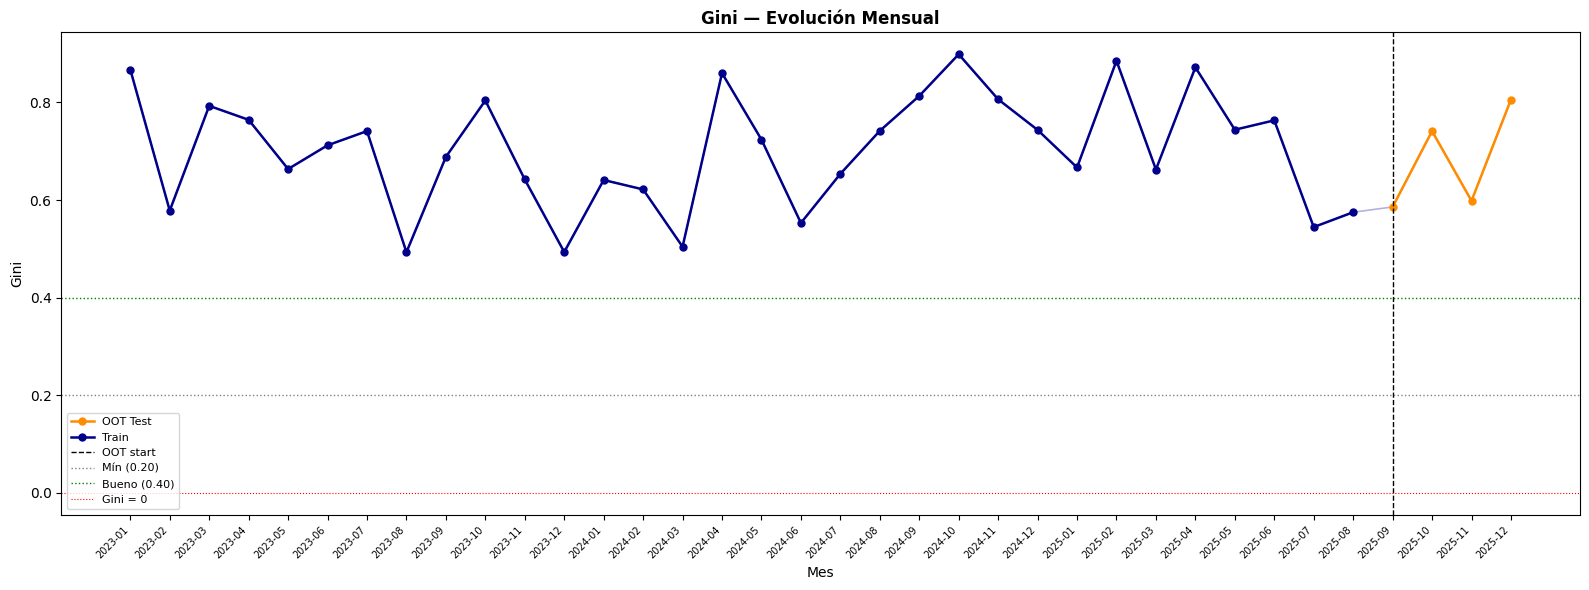

In [11]:
all_months = gini_df['month'].unique().tolist()
month_to_x = {m: i for i, m in enumerate(all_months)}

fig, ax = plt.subplots(figsize=(16, 6))
palette = {'Train': 'darkblue', 'OOT Test': 'darkorange'}

# Línea continua uniendo train + OOT
ax.plot(gini_df['month'].map(month_to_x), gini_df['Gini'],
        color='darkblue', linewidth=1.2, alpha=0.3, zorder=1)

# Puntos por set con color
for label, grp in gini_df.groupby('set'):
    xs = grp['month'].map(month_to_x)
    ax.plot(xs, grp['Gini'], marker='o', markersize=5,
            linewidth=1.8, label=label, color=palette[label], zorder=2)

ax.axvline(month_to_x['2025-09'], color='black', linestyle='--', linewidth=1, label='OOT start')
ax.axhline(0.20, color='grey',  linestyle=':', linewidth=1, label='Mín (0.20)')
ax.axhline(0.40, color='green', linestyle=':', linewidth=1, label='Bueno (0.40)')
ax.axhline(0.00, color='red',   linestyle=':', linewidth=0.8, label='Gini = 0')

ax.set_xticks(range(len(all_months)))
ax.set_xticklabels(all_months, rotation=45, ha='right', fontsize=7)
ax.set_title('Gini — Evolución Mensual', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Gini')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## **2.2 Distribución del Score: Goods vs Bads**

Si las distribuciones de Good y Bad se superponen mucho, el modelo tiene poco poder discriminatorio.

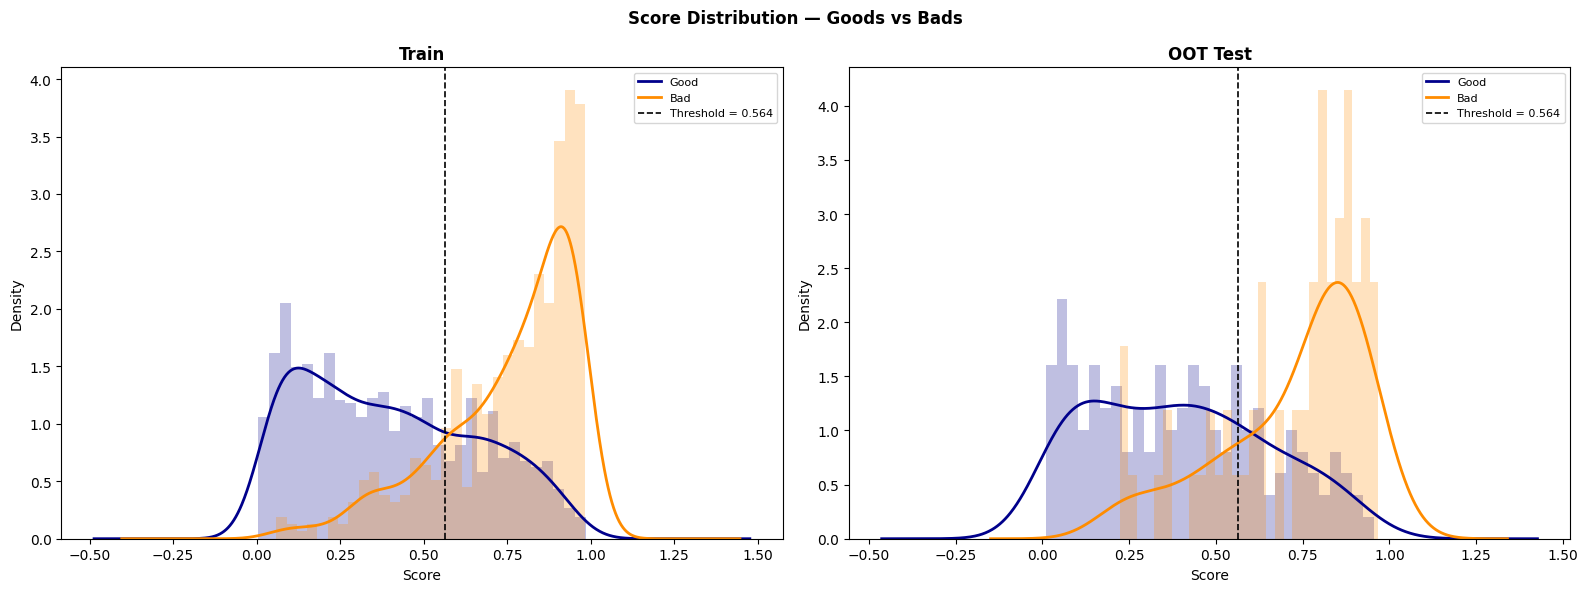

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, df) in zip(axes, [('Train', train), ('OOT Test', test)]):
    for cls, color, name in [(0, 'darkblue', 'Good'), (1, 'darkorange', 'Bad')]:
        subset = df[df[TARGET] == cls]['score']
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=name)
        ax.hist(subset, bins=30, alpha=0.25, color=color, density=True)
    ax.axvline(mdl.threshold, color='black', linestyle='--', linewidth=1.2, label=f'Threshold = {mdl.threshold:.3f}')
    ax.set_title(f'{label}', fontweight='bold')
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)

fig.suptitle('Score Distribution — Goods vs Bads', fontweight='bold')
plt.tight_layout()
plt.show()

# **3. Construcción del Score a partir del Modelo** 

En un modelo de **Credit Scoring**, la **Regresión Logística** produce una probabilidad de incumplimiento (PD):

$$
E(Y \mid X) = P(Y = 1 \mid X) = PD
$$

Sin embargo, en la industria financiera las decisiones no se toman directamente con probabilidades, sino con un score crediticio, que es una transformación monotónica del modelo logístico. La relación entre el modelo logístico y el score se basa en los **odds** (Bad : Good):

$$
Odds = \frac{P(Y=1)}{P(Y=0)} = \frac{p_i}{1 - p_i} = e^{X_i\beta}
$$

**Odds** de 1:50 → por cada 51 clientes, 50 pagan y 1 no. Cuanto más bajo las odds, mejor el cliente. 

Para construir nuestro score usaremos la **inversa del Odds Ratio (Good: Bad)**. Luego se utiliza una transformación lineal para obtener el *Final Scorecard Production*:
$$
Score = Offset + Factor⋅ln(Odds_{Good:Bad})  
$$

Idea: Mayor PD → mayor riesgo → Menor Odds ratio → menor Score.

Donde los parámetros del score se definen mediante tres valores estándar:
- Score base (Score0): Fija el punto central de la escala (ej. 600)
- Odds base (Odds0): Odds asociadas al Score₀ 
- PDO (Points to Double the Odds): Cuántos puntos deben cambiar para duplicar el riesgo (ej. 20 o 30).

**Cálculo de Factor y Offset**
- Factor: Determina qué tan “sensible” es la escala
$$
Factor = \frac{PDO}{ln(2)}
$$

- Offset: Ajusta la escala para que el punto base coincida con Score₀.
$$
Offset = Score0 - Factor * Ln(Odds0)
$$

Por lo tanto, se puede calcular el score final:
$$
Score = Offset + Factor \cdot \ln\left( \frac{1 - PD}{PD} \right)
$$





Flujo Completo del Credit Scoring:
```
Datos del cliente
      ↓
Feature Engineering
      ↓
Transformación WOE
      ↓
Modelo Logístico
      ↓
Probabilidad de Default (PD)
      ↓
Transformación a Score
      ↓
Cutoff de Decisión
      ↓
Aprobación / Rechazo
      ↓
Implementación vía API
```

In [13]:
# ---------------------------
# 1) PARÁMETROS DE ESCALA (negocio)
# ---------------------------
PDO   = 20      # Sensibilidad: cada 20 puntos las odds (Good:Bad) se duplican.
Score0 = 600    # Score base: el "punto de referencia" de tu escala (comunicación/continuidad).
Odds0  = (1 - 0.29) / 0.29  # ≈ 2.45     # Odds0 (Good:Bad) asociadas a Score0. 
                                         # Esto equivale a Good:Bad ≈ 2.45 : 1, es decir: por cada 3.45 cliente 2.45 son Buenos 1 es Malo (~29% PD).
                                         # Quiero que Score0 = 600 represente un cliente promedio (29% de PD)

# ---------------------------
# 2) FACTOR y OFFSET (derivados de la escala)
# ---------------------------
factor = PDO / np.log(2)  # Factor convierte cambios en ln(odds) a puntos respetando el PDO.
offset = Score0 - factor * np.log(Odds0) # Dónde quieres que caiga el score base (Score0)
print(f"Factor: {factor:.2f}, Offset: {offset:.2f}")

# ---------------------------
# 3) PROBABILIDADES DEL MODELO
# ---------------------------
pds = mdl.best_model.predict_proba(train[features])[:,1]  # PD = P(Y=1 | X)

# ---------------------------
# 4) TRANSFORMACIÓN PD -> SCORE (convención Good:Bad)
# ---------------------------
odds = (1 - pds) / pds              # Good:Bad. Cuanto mayor, mejor cliente.
score = offset + factor * np.log(odds)
# Con esta forma, si PD sube -> odds bajan -> ln(odds) baja -> score baja (monotonía correcta).

# ---------------------------
# 5) SALIDA TABULAR
# ---------------------------
df_score = pd.DataFrame({
    'scorecard': score,       # tu score final en puntos
    'odds': np.log(odds),        # ln(Good:Bad) para análisis interno (no es necesario reportar a negocio)
    'prob_default': pds,      # PD del modelo (ya clippeada)
    'target': train[TARGET]   # etiqueta real (0=Good, 1=Bad)
})

print(df_score.head())

Factor: 28.85, Offset: 574.16
    scorecard      odds  prob_default  target
0  591.105695  0.587131      0.357293       0
1  662.357869  3.056543      0.044936       0
2  573.545624 -0.021455      0.505363       0
3  583.254859  0.315042      0.421885       0
4  521.151045 -1.837313      0.862631       1


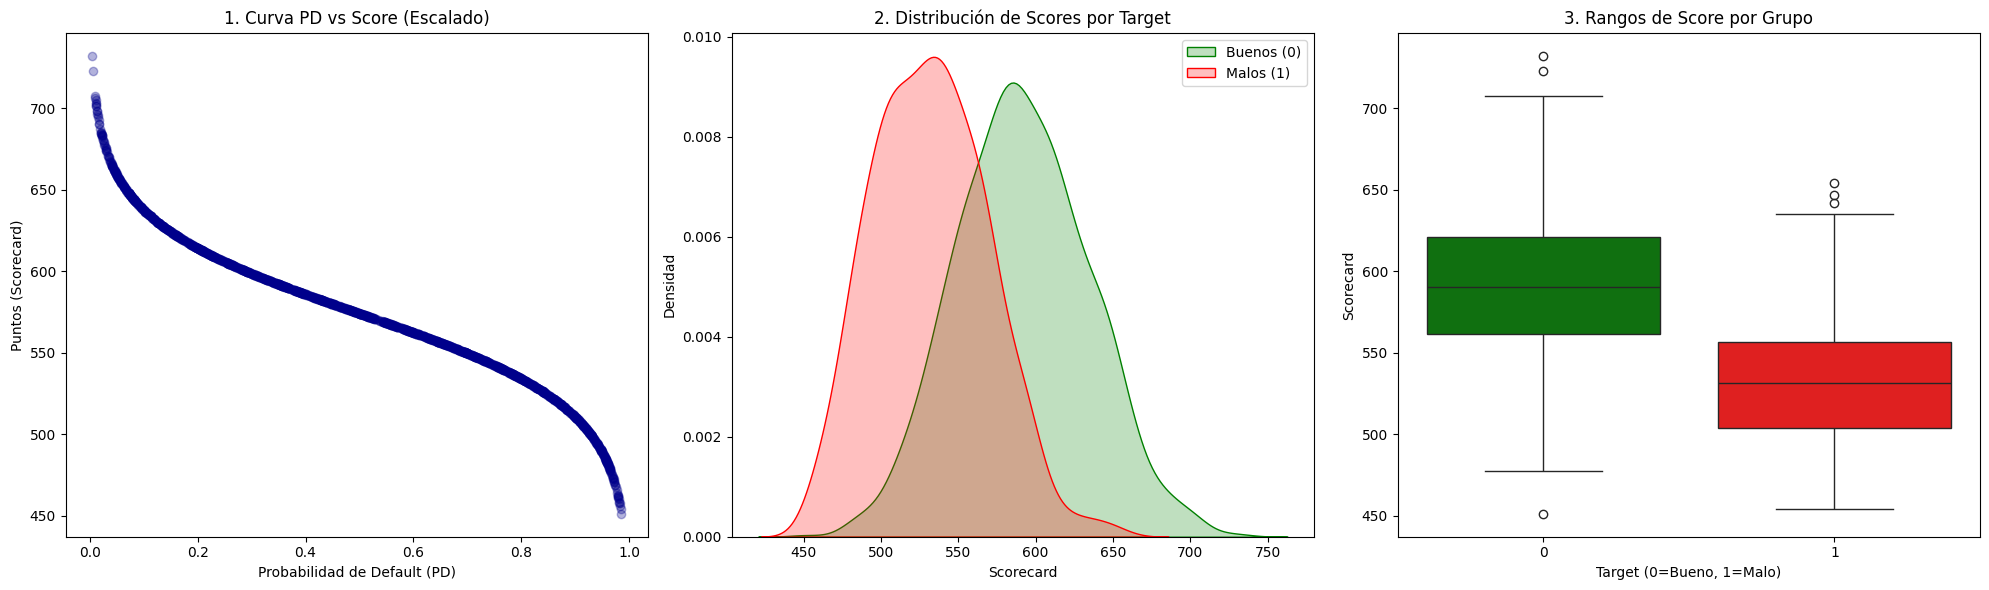

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# --- GRÁFICO 1: Relación Matemática (Validación de la escala) ---
ax[0].scatter(df_score['prob_default'], df_score['scorecard'], alpha=0.3, color='darkblue')
ax[0].set_title('1. Curva PD vs Score (Escalado)')
ax[0].set_xlabel('Probabilidad de Default (PD)')
ax[0].set_ylabel('Puntos (Scorecard)')
ax[0].grid(False)

# --- GRÁFICO 2: Distribución de Scores por Target (Discriminación) ---
# Este es el más importante para negocio: ¿Se separan los grupos?
sns.kdeplot(data=df_score[df_score['target'] == 0], x='scorecard', fill=True, label='Buenos (0)', ax=ax[1], color='green')
sns.kdeplot(data=df_score[df_score['target'] == 1], x='scorecard', fill=True, label='Malos (1)', ax=ax[1], color='red')
ax[1].set_title('2. Distribución de Scores por Target')
ax[1].set_xlabel('Scorecard')
ax[1].set_ylabel('Densidad')
ax[1].legend()

# --- GRÁFICO 3: Boxplot de Score (Outliers y Rangos) ---
sns.boxplot(data=df_score, x='target', y='scorecard', palette={'0': "green", '1': "red"}, ax=ax[2])
ax[2].set_title('3. Rangos de Score por Grupo')
ax[2].set_xlabel('Target (0=Bueno, 1=Malo)')
ax[2].set_ylabel('Scorecard')

plt.tight_layout()
plt.show()

# **4. Determinación del Punto de Corte**

```
Score bajo              Score alto
|----------------|----------------|
   Reject zone        Approve zone
```

## **4.1 KS (Kolmogorov–Smirnov)**

In [15]:
y_true = df_score["target"]
scores = df_score["scorecard"]

risk = -scores # Convertimos score a "riesgo" porque roc_curve asume que valores altos = mayor probabilidad de clase positiva

fpr, tpr, thresholds = roc_curve(y_true, risk)

ks = tpr - fpr
ks_idx = np.argmax(ks)

ks_value = ks[ks_idx]
cutoff_score = -thresholds[ks_idx]

approved = df_score[df_score["scorecard"] >= cutoff_score]
approval_rate = len(approved) / len(df_score)
default_rate = approved["target"].mean()

print("KS:", ks_value)
print("Cutoff óptimo:", cutoff_score)
print("Approval Rate:", round(approval_rate, 4))
print("Default Rate (portfolio):", round(default_rate, 4))

KS: 0.5481041383523896
Cutoff óptimo: 566.7437445548188
Approval Rate: 0.5603
Default Rate (portfolio): 0.0865


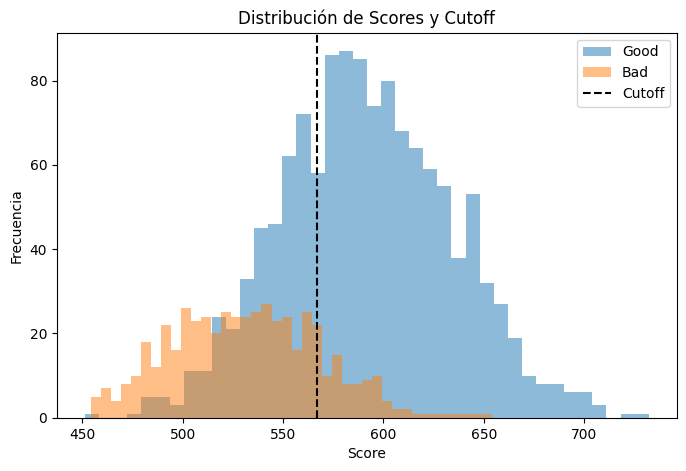

In [16]:
plt.figure(figsize=(8,5))

good = df_score[df_score.target==0]["scorecard"]
bad = df_score[df_score.target==1]["scorecard"]

plt.hist(good, bins=40, alpha=0.5, label="Good")
plt.hist(bad, bins=40, alpha=0.5, label="Bad")

plt.axvline(cutoff_score, color='black', linestyle='--', label="Cutoff")

plt.legend()
plt.title("Distribución de Scores y Cutoff")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.show()

## **4.2 Optimización basada en costos**

$$
Profit=(Good⋅Gain)−(Bad⋅Loss)
$$

In [17]:
# 1. Definimos las pérdidas y ganancias por cada estado de la naturaleza.
profit_matrix = {
    "TP": 50,
    "FP": -50,
    "FN": -250,
    "TN": 100
}

# 2. Probamos diferentes cutoffs del score
cutoffs = np.linspace(
    df_score['scorecard'].min(),
    df_score['scorecard'].max(),
    200
)

# 3. Calculamos el profit para cada cutoff y almacenamos los resultados
results = []

for c in cutoffs:

    approve = df_score['scorecard'] >= c

    TP = ((~approve) & (df_score['target'] == 1)).sum()
    FP = ((~approve) & (df_score['target'] == 0)).sum()
    FN = ((approve) & (df_score['target'] == 1)).sum()
    TN = ((approve) & (df_score['target'] == 0)).sum()

    profit = (
        TP * profit_matrix["TP"] +
        FP * profit_matrix["FP"] +
        FN * profit_matrix["FN"] +
        TN * profit_matrix["TN"]
    )

    results.append({
        "cutoff": c,
        "profit": profit,
        "approval_rate": approve.mean(),
        "default_rate": df_score.loc[approve, "target"].mean()
    })

profit_df = pd.DataFrame(results)
optimal_row = profit_df.loc[profit_df['profit'].idxmax()] # profit_df.loc[profit_df['profit'].idxmax()][0]

print(optimal_row)

cutoff             555.753129
profit           74100.000000
approval_rate        0.641488
default_rate         0.114236
Name: 74, dtype: float64


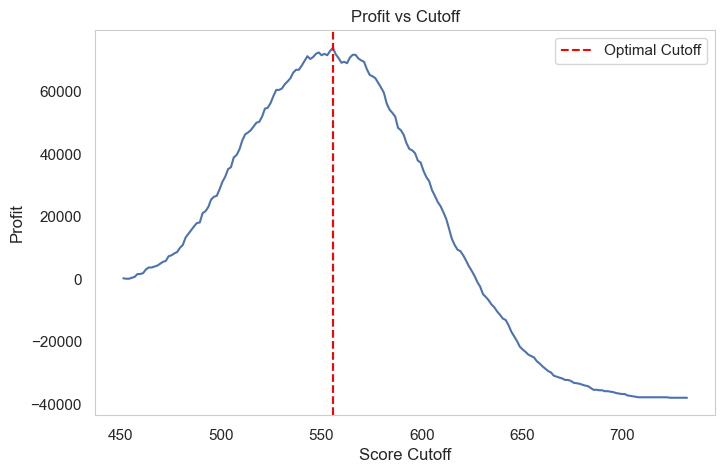

In [60]:
plt.figure(figsize=(8,5))
plt.plot(profit_df.cutoff, profit_df.profit)
plt.axvline(optimal_row.cutoff, color='red', linestyle='--', label='Optimal Cutoff')
plt.title("Profit vs Cutoff")
plt.xlabel("Score Cutoff")
plt.ylabel("Profit")
plt.legend()

plt.show()

# **5. Simulación de Decisión Crediticia**

```
JSON input
   ↓
preprocessing.py
   ↓
feature_engineering.py
   ↓
modelo.pkl
   ↓
predict_proba
   ↓
scorecard
   ↓
cutoff
   ↓
decision
```

Instalar dependencias: 
```
pip install fastapi uvicorn
```

In [44]:
export(
    model    = mdl.best_model,   # tu estimador sklearn entrenado
    fe       = fe,               # instancia FeatureEngineering post run_all()
    features = features,         # lista de columnas woe_* que entran al modelo
    cutoff   = cutoff_score,     # tu cutoff óptimo
)

✅  model.pkl       → C:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\models\s08\api\model.pkl
✅  woe_maps.pkl    → C:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\models\s08\api\woe_maps.pkl  (31 features)
✅  config.json     → C:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\models\s08\api\config.json

   cutoff   = 566.7437
   features = 26  →  ['woe_age', 'woe_education_level', 'woe_loan_amount', 'woe_loan_tenure_months'] ...
   PDO=20.0 | Score0=600.0 | Odds0=2.4483

🎯  Listo. Copia la carpeta 'C:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\models\s08\api/' junto a main.py y levanta la API.
